In [1]:
!pip install -q torch torchvision scikit-learn matplotlib seaborn tensorflow

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.utils as vutils

import matplotlib.pyplot as plt
import numpy as np
import time

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import DataLoader, random_split, TensorDataset

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

trainset, valset = random_split(dataset, [train_size, val_size])

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
valloader = DataLoader(valset, batch_size=64)
testloader = DataLoader(testset, batch_size=64)

100%|██████████| 170M/170M [00:04<00:00, 40.5MB/s]


In [5]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(128*4*4,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,10)
        )

    def forward(self,x):

        x = self.conv(x)
        x = x.view(x.size(0),-1)

        return self.fc(x)

In [6]:
def train_model(model, epochs=3):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses=[]
    val_losses=[]

    start=time.time()

    for epoch in range(epochs):

        model.train()
        total_loss=0

        for images,labels in trainloader:

            images,labels = images.to(device),labels.to(device)

            optimizer.zero_grad()

            outputs=model(images)

            loss=criterion(outputs,labels)

            loss.backward()

            optimizer.step()

            total_loss+=loss.item()

        train_losses.append(total_loss/len(trainloader))

        model.eval()
        val_loss=0

        with torch.no_grad():

            for images,labels in valloader:

                images,labels=images.to(device),labels.to(device)

                outputs=model(images)

                loss=criterion(outputs,labels)

                val_loss+=loss.item()

        val_losses.append(val_loss/len(valloader))

        print("Epoch",epoch+1,"Train:",train_losses[-1],"Val:",val_losses[-1])

    time_taken=time.time()-start

    return train_losses,val_losses,time_taken

In [7]:
cnn_model = SimpleCNN()

cnn_train, cnn_val, cnn_time = train_model(cnn_model)

Epoch 1 Train: 1.4698215378761292 Val: 1.1371753276533383
Epoch 2 Train: 1.0602246486663818 Val: 0.9328278678997307
Epoch 3 Train: 0.8868872004508972 Val: 0.859482907565536


In [8]:
resnet = models.resnet18(pretrained=True)

for param in resnet.parameters():
    param.requires_grad=False

resnet.fc = nn.Linear(resnet.fc.in_features,10)

resnet_train,resnet_val,resnet_time = train_model(resnet)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s]


Epoch 1 Train: 1.7562118762969972 Val: 1.6231597206395143
Epoch 2 Train: 1.6039531574249268 Val: 1.5951326675475783
Epoch 3 Train: 1.5845684934616089 Val: 1.610257559521183


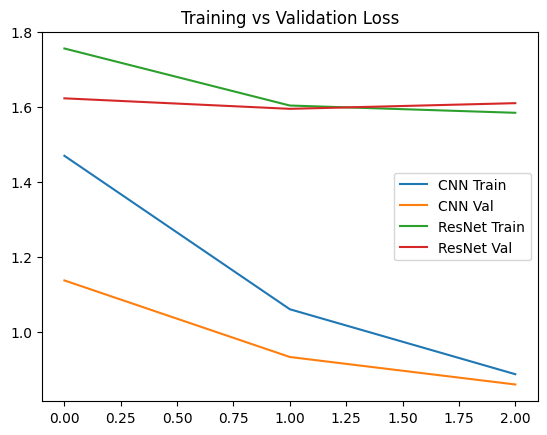

In [9]:
plt.plot(cnn_train,label="CNN Train")
plt.plot(cnn_val,label="CNN Val")

plt.plot(resnet_train,label="ResNet Train")
plt.plot(resnet_val,label="ResNet Val")

plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [10]:
def evaluate(model):

    model.eval()

    y_true=[]
    y_pred=[]

    correct=0
    total=0

    with torch.no_grad():

        for images,labels in testloader:

            images,labels = images.to(device),labels.to(device)

            outputs=model(images)

            _,pred=torch.max(outputs,1)

            correct+=(pred==labels).sum().item()
            total+=labels.size(0)

            y_true.extend(labels.cpu())
            y_pred.extend(pred.cpu())

    return 100*correct/total,y_true,y_pred

CNN Accuracy: 70.89


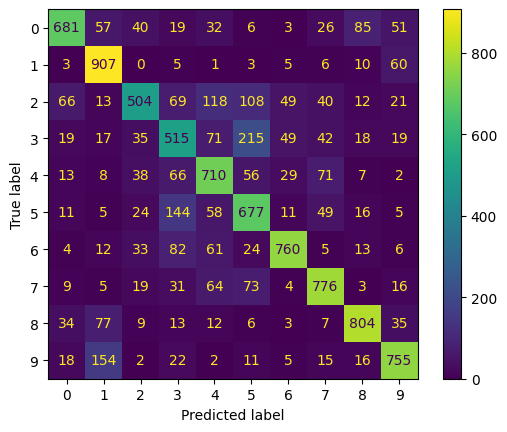

In [11]:
cnn_acc,y_true,y_pred = evaluate(cnn_model)

print("CNN Accuracy:",cnn_acc)

cm=confusion_matrix(y_true,y_pred)

ConfusionMatrixDisplay(cm).plot()

plt.show()

In [12]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [13]:
max_features = 10000
max_len = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features)

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

X_train = torch.tensor(X_train)
y_train = torch.tensor(y_train)

X_test = torch.tensor(X_test)
y_test = torch.tensor(y_test)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [15]:
class TextModel(nn.Module):

    def __init__(self,model_type):

        super().__init__()

        self.embedding = nn.Embedding(max_features,64)

        if model_type=="RNN":
            self.rnn = nn.RNN(64,64,batch_first=True)

        elif model_type=="LSTM":
            self.rnn = nn.LSTM(64,64,batch_first=True)

        else:
            self.rnn = nn.GRU(64,64,batch_first=True)

        self.fc = nn.Linear(64,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):

        x=self.embedding(x)

        out,_ = self.rnn(x)

        out = out[:,-1,:]

        return self.sigmoid(self.fc(out))

In [16]:
def train_text(model_type):

    model=TextModel(model_type).to(device)

    criterion=nn.BCELoss()
    optimizer=optim.Adam(model.parameters(),lr=0.001)

    losses=[]

    for epoch in range(3):

        total=0

        for Xb,yb in train_loader:

            Xb=Xb.to(device)
            yb=yb.float().to(device)

            outputs=model(Xb).squeeze()

            loss=criterion(outputs,yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total+=loss.item()

        losses.append(total/len(train_loader))

        print(model_type,"Epoch",epoch+1,"Loss",losses[-1])

    return model,losses

In [17]:
rnn_model,rnn_loss = train_text("RNN")
lstm_model,lstm_loss = train_text("LSTM")
gru_model,gru_loss = train_text("GRU")

RNN Epoch 1 Loss 0.648600730825873
RNN Epoch 2 Loss 0.5803731255366674
RNN Epoch 3 Loss 0.5160128132004262
LSTM Epoch 1 Loss 0.6103469166152008
LSTM Epoch 2 Loss 0.47509516146786684
LSTM Epoch 3 Loss 0.3650820259471684
GRU Epoch 1 Loss 0.6290821930788972
GRU Epoch 2 Loss 0.45158166909004416
GRU Epoch 3 Loss 0.34386395836425254


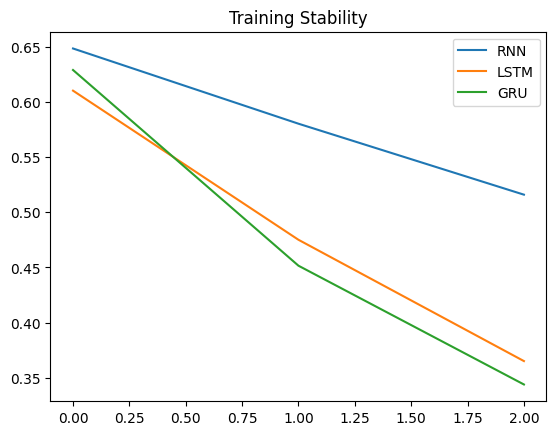

In [18]:
plt.plot(rnn_loss,label="RNN")
plt.plot(lstm_loss,label="LSTM")
plt.plot(gru_loss,label="GRU")

plt.legend()
plt.title("Training Stability")
plt.show()

In [19]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(dataset,batch_size=64,shuffle=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 207kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.89MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.8MB/s]


In [20]:
latent_dim = 100

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(latent_dim,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256,512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512,1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),

            nn.Linear(1024,784),
            nn.Tanh()
        )

    def forward(self,z):

        img = self.model(z)

        return img.view(-1,1,28,28)


class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(784,512),
            nn.LeakyReLU(0.2),

            nn.Linear(512,256),
            nn.LeakyReLU(0.2),

            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self,img):

        img = img.view(img.size(0),-1)

        return self.model(img)

In [21]:
# CELL 18 — Train GAN (Improved)

epochs = 20
latent_dim = 100

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0002)

g_losses = []
d_losses = []

for epoch in range(epochs):

    for imgs, _ in loader:

        real = imgs.to(device)

        batch = real.size(0)

        real_labels = torch.ones(batch,1).to(device)
        fake_labels = torch.zeros(batch,1).to(device)

        # -----------------------
        # Train Discriminator
        # -----------------------

        opt_D.zero_grad()

        real_loss = criterion(D(real), real_labels)

        z = torch.randn(batch, latent_dim).to(device)

        fake = G(z)

        fake_loss = criterion(D(fake.detach()), fake_labels)

        d_loss = real_loss + fake_loss

        d_loss.backward()

        opt_D.step()

        # -----------------------
        # Train Generator
        # -----------------------

        opt_G.zero_grad()

        g_loss = criterion(D(fake), real_labels)

        g_loss.backward()

        opt_G.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

    # Save generated images
    vutils.save_image(
        fake[:64],
        f"epoch_{epoch+1}.png",
        nrow=8,
        normalize=True
    )

Epoch 1/20 | D Loss: 0.0485 | G Loss: 12.6361
Epoch 2/20 | D Loss: 0.1510 | G Loss: 4.4842
Epoch 3/20 | D Loss: 0.2052 | G Loss: 4.5343
Epoch 4/20 | D Loss: 0.1892 | G Loss: 5.4550
Epoch 5/20 | D Loss: 0.5217 | G Loss: 4.0174
Epoch 6/20 | D Loss: 0.2104 | G Loss: 4.0078
Epoch 7/20 | D Loss: 0.1263 | G Loss: 4.8464
Epoch 8/20 | D Loss: 0.4983 | G Loss: 4.4570
Epoch 9/20 | D Loss: 0.3848 | G Loss: 4.0303
Epoch 10/20 | D Loss: 0.2013 | G Loss: 5.8996
Epoch 11/20 | D Loss: 0.8023 | G Loss: 2.7084
Epoch 12/20 | D Loss: 0.8641 | G Loss: 4.0760
Epoch 13/20 | D Loss: 0.6735 | G Loss: 3.4272
Epoch 14/20 | D Loss: 0.9772 | G Loss: 3.2272
Epoch 15/20 | D Loss: 0.8545 | G Loss: 2.9146
Epoch 16/20 | D Loss: 0.7123 | G Loss: 3.3316
Epoch 17/20 | D Loss: 1.2682 | G Loss: 1.3493
Epoch 18/20 | D Loss: 0.8409 | G Loss: 1.8353
Epoch 19/20 | D Loss: 0.7652 | G Loss: 2.3706
Epoch 20/20 | D Loss: 0.7627 | G Loss: 4.6155


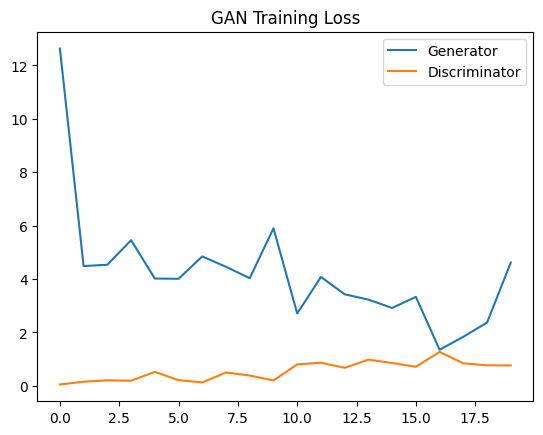

In [22]:
plt.plot(g_losses,label="Generator")
plt.plot(d_losses,label="Discriminator")

plt.legend()
plt.title("GAN Training Loss")

plt.show()

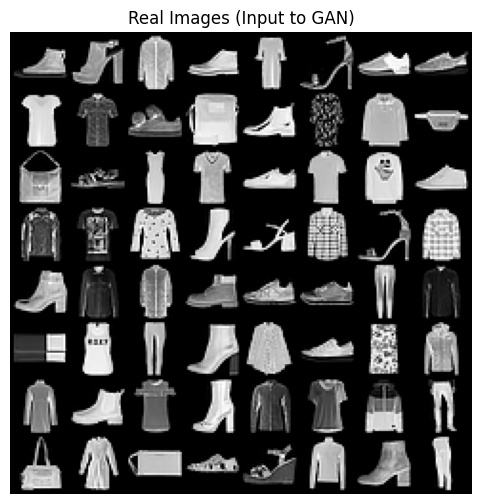

In [23]:
# Show real images used as GAN input

dataiter = iter(loader)
images, labels = next(dataiter)

# Take first 64 images
real_images = images[:64]

# Create grid
grid = torchvision.utils.make_grid(real_images, nrow=8, normalize=True)

plt.figure(figsize=(6,6))
plt.title("Real Images (Input to GAN)")
plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.show()